# Initial Exploratory Data Analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#DATA SET BASIC INFO

# Load dataset
file_path = "sg_studentdata_cleaned.xlsx"  
df = pd.read_excel(file_path)

# Display basic info
print("Dataset Overview:")
print(df.info())

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71754 entries, 0 to 71753
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Centre             71754 non-null  object        
 1   Programme          71754 non-null  object        
 2   Area               71754 non-null  object        
 3   Region             71754 non-null  object        
 4   Sub Region         70946 non-null  object        
 5   Country            71754 non-null  object        
 6   Branch URN         71754 non-null  object        
 7   Group URN          71754 non-null  object        
 8   Lead Source        71754 non-null  object        
 9   Student ID         71754 non-null  int64         
 10  Booking ID         71754 non-null  int64         
 11  Nationality        71754 non-null  object        
 12  IntakeYear         71754 non-null  int64         
 13  IntakeQuarter      71754 non-null  int64   

In [6]:
# Display summary statistics
print("\nSummary Statistics:")
print(df.describe())

# Check for missing values
missing_values = df.isnull().sum()
print("\nMissing Values:")
print(missing_values[missing_values > 0])


Summary Statistics:
         Student ID    Booking ID    IntakeYear  IntakeQuarter  \
count  7.175400e+04  7.175400e+04  71754.000000   71754.000000   
mean   2.814269e+06  4.394030e+07   2023.238635       2.731388   
min    3.798990e+05  2.475583e+07   2023.000000       1.000000   
25%    2.787310e+06  4.385661e+07   2023.000000       3.000000   
50%    2.823211e+06  4.398754e+07   2023.000000       3.000000   
75%    2.846213e+06  4.415893e+07   2023.000000       3.000000   
max    9.023152e+07  4.477511e+07   2024.000000       4.000000   
std    4.650807e+05  4.218965e+05      0.426252       0.994142   

                 Application Date                   Offered Date  \
count                       71754                          51892   
mean   2023-05-03 05:07:36.660256  2023-05-03 02:04:00.869498112   
min           2022-07-02 00:00:00            2022-07-05 00:00:00   
25%           2023-01-31 00:00:00            2023-01-28 00:00:00   
50%           2023-04-27 00:00:00           

Data set overview: 
-The dataset consists of 71,754 student records across 26 columns, including categorical (e.g., Programme, Region), numerical (e.g., Tuition Fees, Discount), and datetime fields (e.g., Application Date, Confirmation Date).
-Missing data is substantial in key progression columns, particularly in Confirmation Date (91% missing), Arrived Date (94% missing), and Discount Type (96.5% missing), which may limit specific analyses.

Applications:
-Application dates range from July 2022 to July 2024, with an average submission date around May 2023.
Offers are made relatively quickly after application, with the mean offered date nearly matching the mean application date (~May 2023).
-Confirmation and arrival rates are very low:
Only 6,436 students (8.9%) reached confirmation stage.
Only 4,088 students (5.7%) arrived, confirming a significant drop-off.
Cancellations are extremely high, with 67,007 cases (93.4%), reinforcing the high attrition rate in the process.

Financial:
-Tuition fees range from £6,950 to £29,960, with a median of £19,250. Net value follows the tuition fee trend closely, though some cases report negative or zero values, potentially indicating refunds or waivers.
-Discount values range from £0 to £9,500, with an average of £91, but the median discount is £0, suggesting that a large proportion of students receive no discount.

Discounts:
-The average discount is only £91, despite the maximum reaching £9,500.
-The high standard deviation (£551.75) suggests large disparities in discount allocation, possibly favouring specific regions, centres, or student profiles.
-Given the low confirmation and registration rates, an analysis is needed to determine whether higher discounts lead to increased enrolments.

Missing values in key stages:
-Discount Type (96.5% missing) → This will require either imputation, classification based on discount amounts, or a discount clustering approach.
-Confirmation & Arrival Dates (91%-94% missing) → These missing values suggest students either dropped out before reaching these stages or were never confirmed.
-Cancellation Date (93.4% recorded) → A separate cancellation trend analysis might reveal if cancellations are seasonal, region-specific, or discount-dependent.
-Progression & Registration Columns (95%+ missing) → A detailed review is required to confirm if this is due to incomplete data collection or an actual trend in low progression rates.

# Discount Distribution Analysis
## Overview

In [11]:
#GLOBAL DISCOUNT ANALYSIS

# Convert relevant columns to numeric or datetime
df["Registered"] = pd.to_numeric(df["Registered"], errors="coerce")
df["Confirmation Date"] = pd.to_datetime(df["Confirmation Date"], errors="coerce")

# Create a new column indicating whether a student confirmed (1 if confirmed, 0 otherwise)
df["Confirmed"] = df["Confirmation Date"].notna().astype(int)

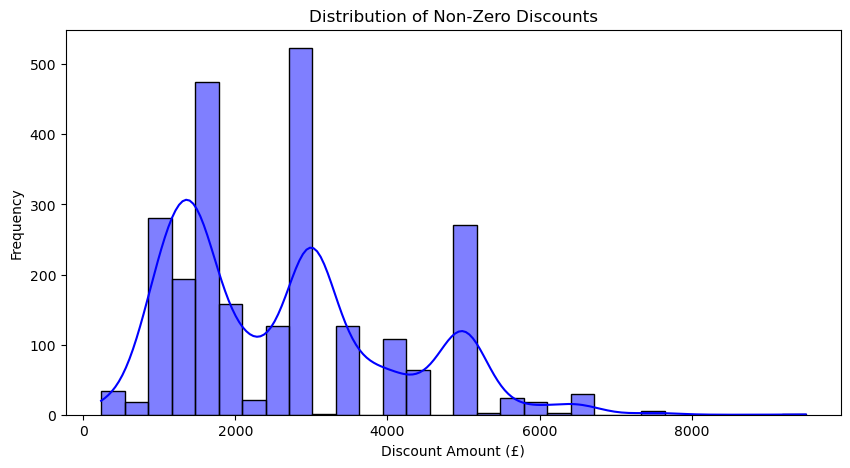

In [13]:
# Distribution of non-zero discounts
df_nonzero_discount = df[df["Discount"] > 0]

plt.figure(figsize=(10, 5))
sns.histplot(df_nonzero_discount["Discount"], bins=30, kde=True, color="blue")
plt.title("Distribution of Non-Zero Discounts")
plt.xlabel("Discount Amount (£)")
plt.ylabel("Frequency")
plt.show()


Most discounts fall between £500 and £4,000, suggesting a general policy where discounts rarely exceed these values.
There are several peaks, indicating commonly awarded discount amounts, potentially reflecting standardized discount tiers.
Discounts beyond £6,000 are rare, suggesting they are likely reserved for specific cases, such as high-priority students or special promotions.

## By Key Dimension
### Centre

C:\Users\Jessy\AppData\Local\Temp\ipykernel_20652\98567447.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Centre", y="Discount", data=discount_analysis, palette="Blues_d")


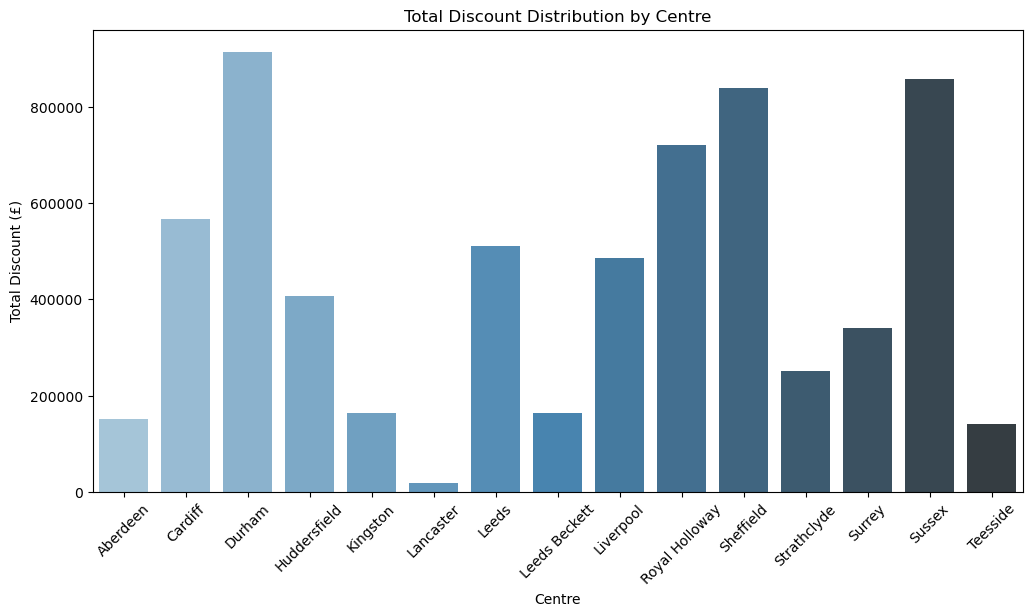

In [16]:
# Total discounts by Centre

discount_analysis = df.groupby(["Centre"])["Discount"].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x="Centre", y="Discount", data=discount_analysis, palette="Blues_d")
plt.xticks(rotation=45)
plt.title("Total Discount Distribution by Centre")
plt.ylabel("Total Discount (£)")
plt.xlabel("Centre")
plt.show()

Some centres receive significantly higher total discounts than others, indicating disparities in discount allocation.
Durham, Royal Holloway, Sheffield, and Sussex appear to have received the highest total discounts, while smaller centres have received much lower amounts.
Possible reasons for this variation:
-These centres may have higher student intake.
-They may attract students who require larger discounts to enroll.
-They may be part of a strategic initiative to boost enrolments in specific locations.


### Programme

C:\Users\Jessy\AppData\Local\Temp\ipykernel_20652\1972870335.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Programme", y="Discount", data=discount_programme, palette="Greens_d")


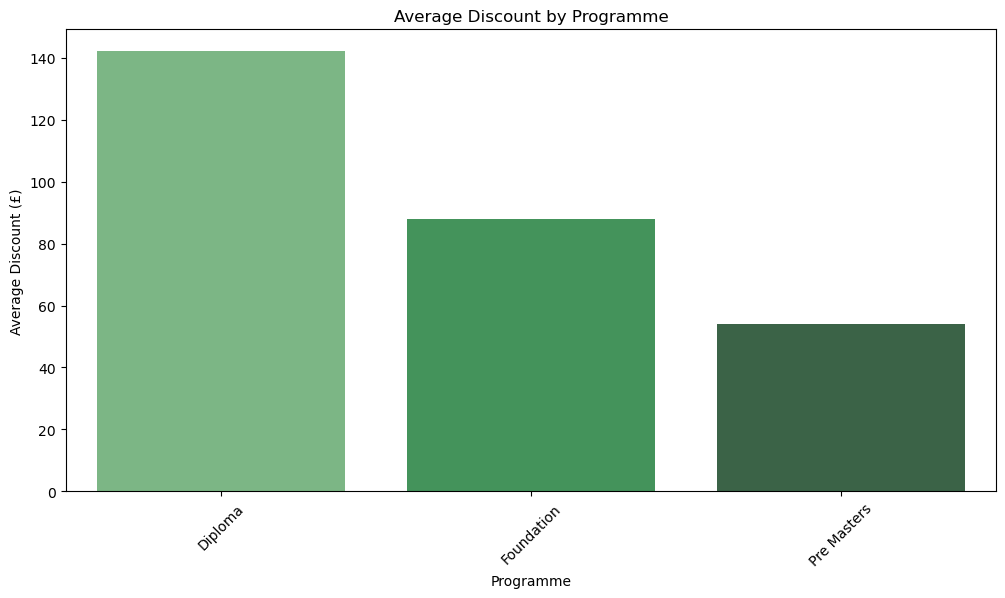

In [19]:
# Average discount by programme

discount_programme = df.groupby(["Programme"])["Discount"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x="Programme", y="Discount", data=discount_programme, palette="Greens_d")
plt.xticks(rotation=45)
plt.title("Average Discount by Programme")
plt.ylabel("Average Discount (£)")
plt.xlabel("Programme")
plt.show()

Diploma and Foundation programmes receive the highest average discounts, whereas Pre-Masters students receive significantly lower discounts.
This may indicate that the institution prioritizes attracting students at the earlier stages of their academic journey with higher financial incentives.
The lower average discount for Pre-Masters suggests that:
-These students might be more willing to pay full tuition.
-Discounts may not be as necessary to attract students at this level.

### Lead Source

C:\Users\Jessy\AppData\Local\Temp\ipykernel_20652\3961591143.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Lead Source", y="sum", data=discount_agent, palette="Oranges_d")


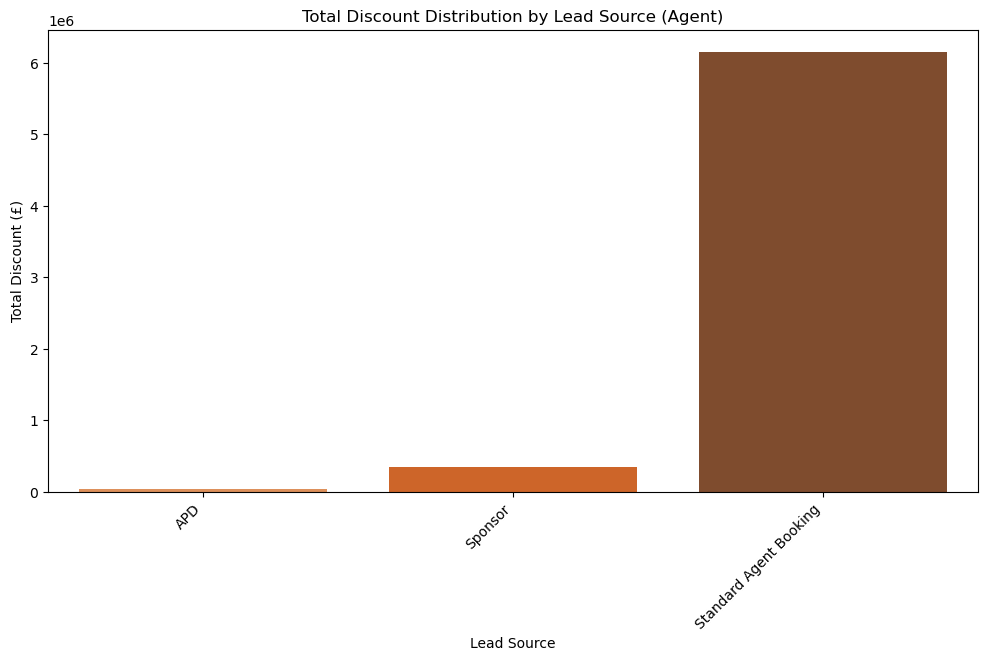

In [23]:
# Total discount distribution by lead source (Agent)

discount_agent = df.groupby(["Lead Source"])["Discount"].agg(["sum", "mean"]).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x="Lead Source", y="sum", data=discount_agent, palette="Oranges_d")
plt.xticks(rotation=45, ha="right")
plt.title("Total Discount Distribution by Lead Source (Agent)")
plt.ylabel("Total Discount (£)")
plt.xlabel("Lead Source")
plt.show()

Standard Agent Booking has received the highest total discounts by a large margin.
Sponsored students and APD (possibly a specific funding program) receive significantly lower total discounts.
This suggests that agents play a major role in the allocation of discounts, and further investigation is needed to see whether discounts provided via agents are effective in boosting confirmation rates.

C:\Users\Jessy\AppData\Local\Temp\ipykernel_20652\2066969578.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Lead Source", y="mean", data=discount_agent, palette="Purples_d")


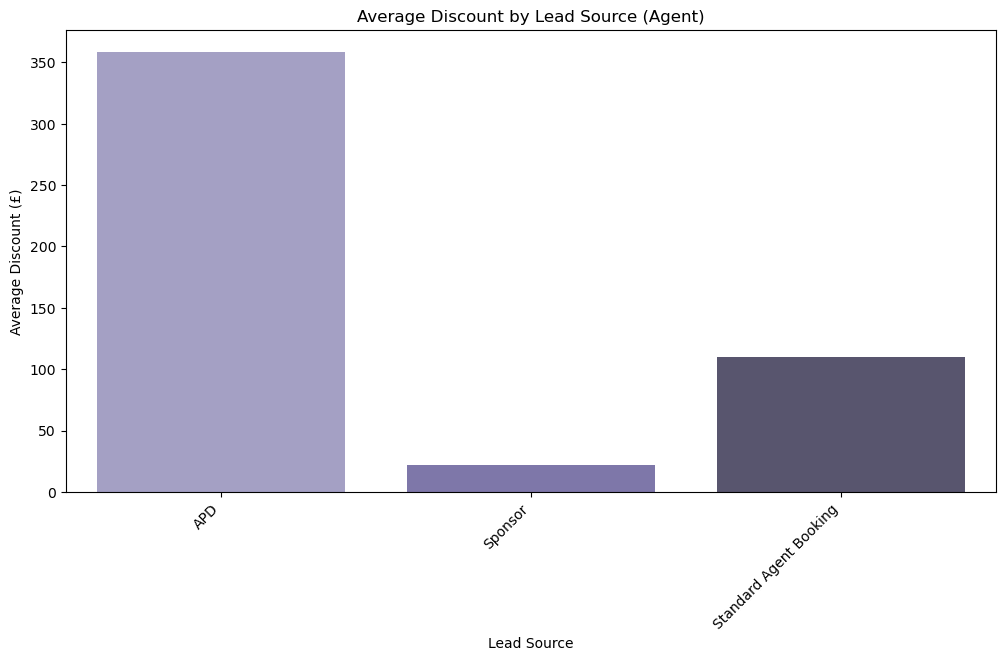

In [26]:
# Average discount by lead source (Agent)

plt.figure(figsize=(12, 6))
sns.barplot(x="Lead Source", y="mean", data=discount_agent, palette="Purples_d")
plt.xticks(rotation=45, ha="right")
plt.title("Average Discount by Lead Source (Agent)")
plt.ylabel("Average Discount (£)")
plt.xlabel("Lead Source")
plt.show()

APD students receive the highest average discount, even though their total allocated discount is lower.
Standard Agent Bookings receive lower average discounts, despite getting the highest total discount allocation.
This suggests that students recruited through agents receive smaller but more frequent discounts, while certain sponsorship programs provide higher per-student discounts.


C:\Users\Jessy\AppData\Local\Temp\ipykernel_20652\677945159.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Region", y="sum", data=discount_region, palette="Reds_d")


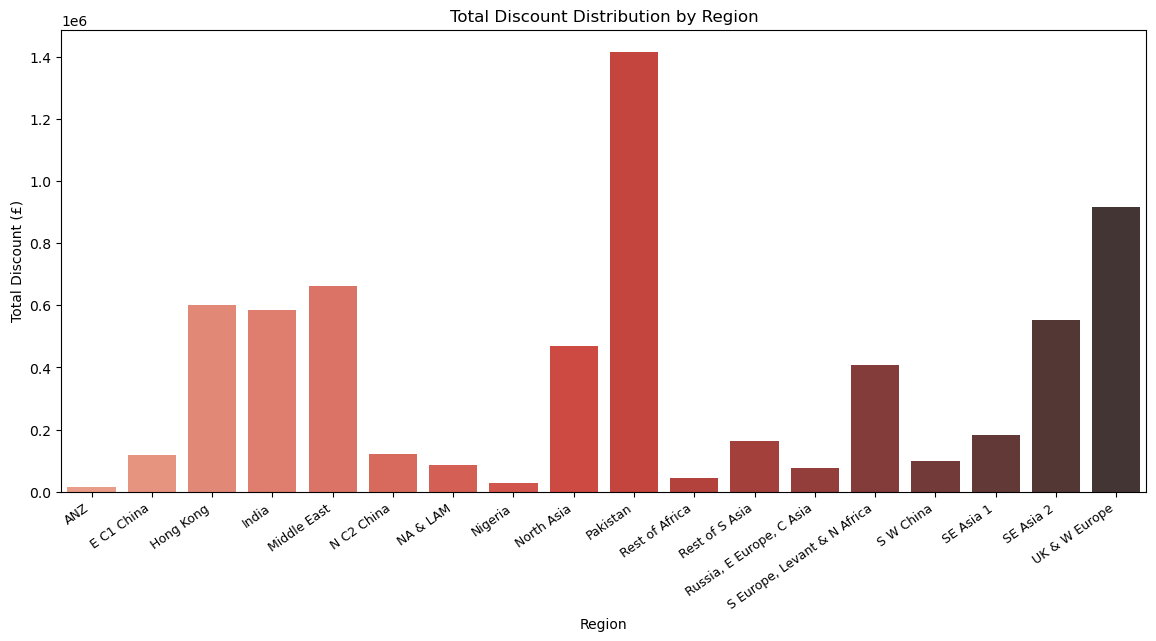

In [29]:
# Total discount distribution by region 

discount_region = df.groupby(["Region"])["Discount"].agg(["sum", "mean"]).reset_index()

plt.figure(figsize=(14, 6))
sns.barplot(x="Region", y="sum", data=discount_region, palette="Reds_d")
plt.xticks(rotation=35, ha="right", fontsize=9)  # Adjust rotation and font size for readability
plt.title("Total Discount Distribution by Region")
plt.ylabel("Total Discount (£)")
plt.xlabel("Region")
plt.show()

Pakistan, Middle East, and the UK & Western Europe receive the highest total discounts.
Some regions receive significantly lower total discounts, indicating either lower student numbers or fewer discount policies in those areas.
The reason behind high discount allocation in Pakistan and Southeast Asia needs further analysis—this could be due to economic factors, marketing focus, or historical enrolment trends.


C:\Users\Jessy\AppData\Local\Temp\ipykernel_20652\3827083969.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Region", y="mean", data=discount_region, palette="Blues_d")


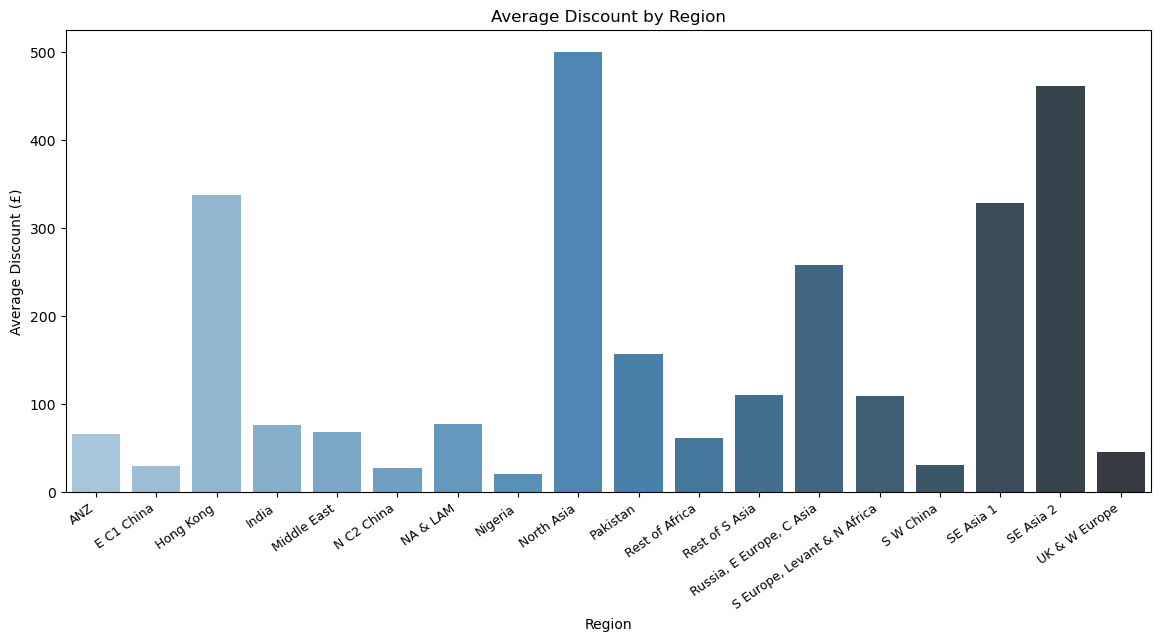

In [40]:
# Average discount by region

plt.figure(figsize=(14, 6))
sns.barplot(x="Region", y="mean", data=discount_region, palette="Blues_d")
plt.xticks(rotation=35, ha="right", fontsize=9)
plt.title("Average Discount by Region")
plt.ylabel("Average Discount (£)")
plt.xlabel("Region")
plt.show()

North Asia and Southeast Asia 2 receive the highest average discounts, suggesting that students from these regions may require higher incentives to enroll.
Regions such as India and China receive lower average discounts, despite having high student volumes.
Understanding why certain regions receive higher discounts can help refine discount strategies to maximize impact while minimizing unnecessary financial incentives.

# Discount Effectiveness Analysis (Discount vs Confirmation Rate)
## By Key Dimension
### Overview

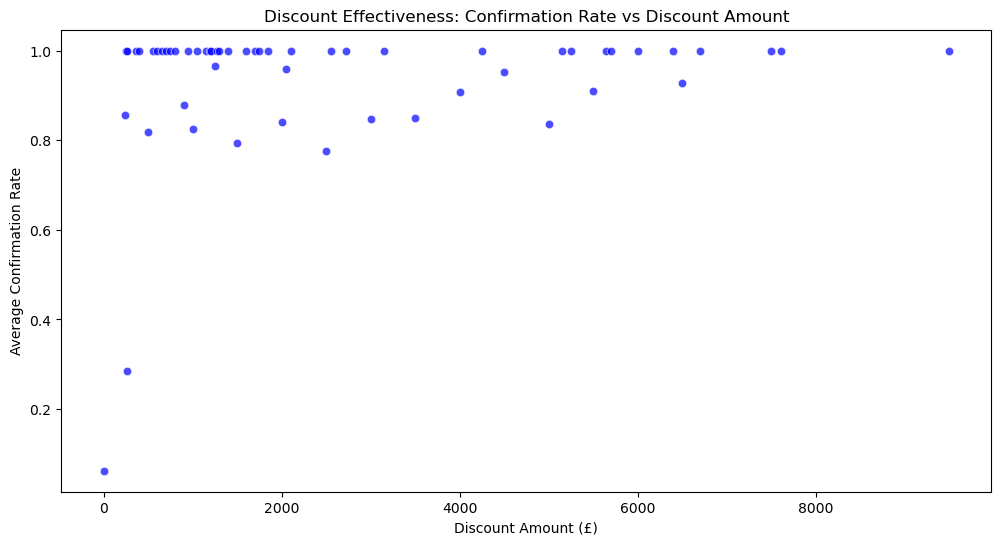

In [55]:
# Discount effectiveness: Confirmation rate vs discount amount

df_discount_effectiveness = df.groupby("Discount")["Confirmed"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.scatterplot(x="Discount", y="Confirmed", data=df_discount_effectiveness, alpha=0.7, color="blue")
plt.title("Discount Effectiveness: Confirmation Rate vs Discount Amount")
plt.xlabel("Discount Amount (£)")
plt.ylabel("Average Confirmation Rate")
plt.show()

Higher discount amounts generally correlate with higher confirmation rates, but with some variability.
The confirmation rate remains consistently high (near 100%) for many discount levels, indicating that most students who receive discounts go on to confirm.
Lower discount amounts show more scattered confirmation rates, suggesting that smaller discounts are not as strong a determining factor in student commitment.
This visualization implies that discounts may influence student decisions, but they are not the only factor—other elements like programme reputation, location, or visa policies may also impact confirmations.

### Lead Source

C:\Users\Jessy\AppData\Local\Temp\ipykernel_20652\2635999868.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Lead Source", y="Confirmed", data=df_discount_lead, palette="coolwarm")


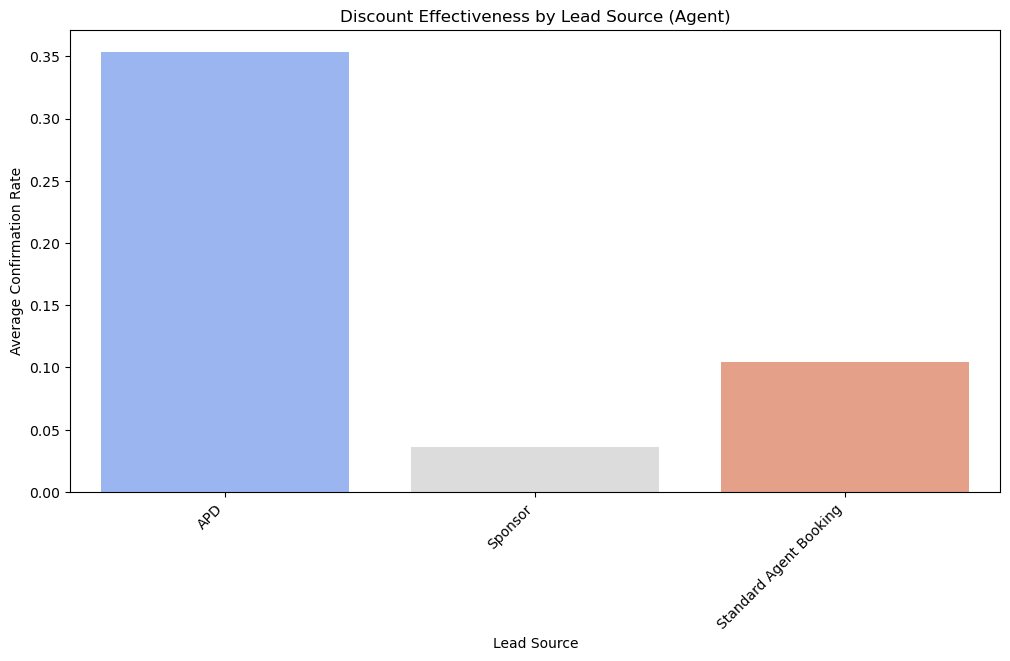

In [47]:
# Discount effectiveness by lead source (Agent)

df_discount_lead = df.groupby("Lead Source")["Confirmed"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x="Lead Source", y="Confirmed", data=df_discount_lead, palette="coolwarm")
plt.xticks(rotation=45, ha="right")
plt.title("Discount Effectiveness by Lead Source (Agent)")
plt.ylabel("Average Confirmation Rate")
plt.xlabel("Lead Source")
plt.show()

APD students have the highest confirmation rates, even though their total discount allocation is relatively low.
Standard Agent Bookings have the lowest confirmation rates, despite receiving the largest portion of total discounts.
This suggests that discounts alone may not be enough to drive confirmations in agent-led recruitment, and other factors like service quality, reputation, or student support could play a role.

### By Region

C:\Users\Jessy\AppData\Local\Temp\ipykernel_20652\1322598009.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Region", y="Confirmed", data=df_discount_region, palette="viridis")


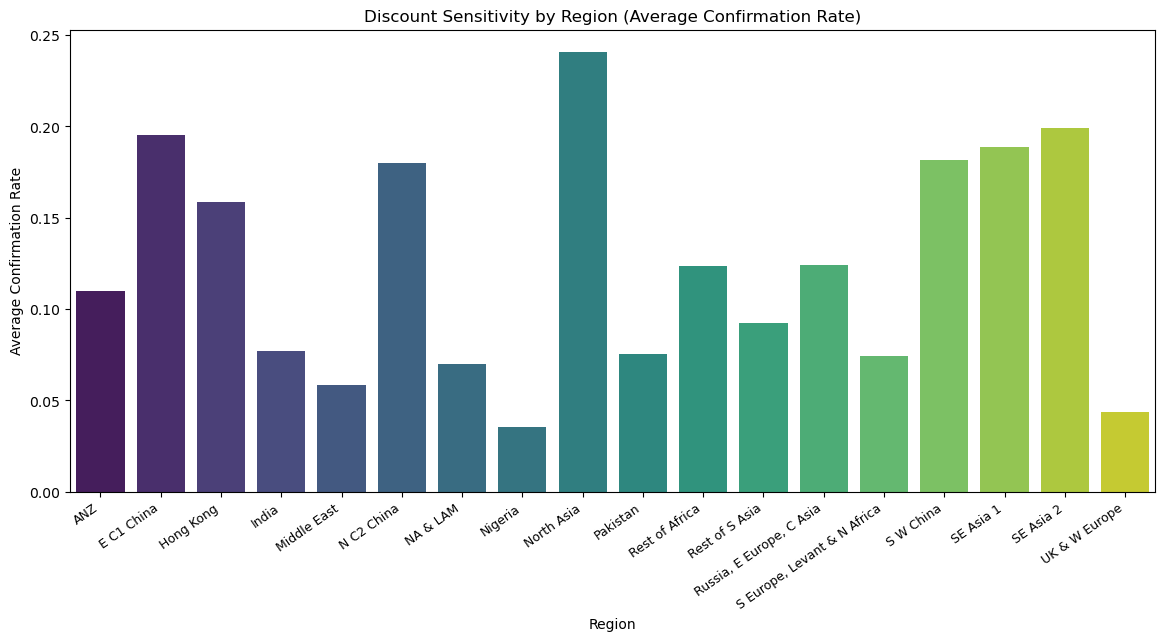

In [53]:
# Discount sensitivity by region 

df_discount_region = df.groupby("Region")["Confirmed"].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.barplot(x="Region", y="Confirmed", data=df_discount_region, palette="viridis")
plt.xticks(rotation=35, ha="right", fontsize=9)  # Ensuring labels do not overlap
plt.title("Discount Sensitivity by Region (Average Confirmation Rate)")
plt.ylabel("Average Confirmation Rate")
plt.xlabel("Region")
plt.show()

Some regions (e.g., North Asia and certain parts of Southeast Asia) have higher confirmation rates, indicating strong responsiveness to discounts.
Regions such as Nigeria and the Middle East show weaker confirmation rates, implying that discounts alone may not be enough to convert students from these areas.
This suggests that discount strategies should be region-specific—higher discounts may be more effective in some regions than others.

### By Center

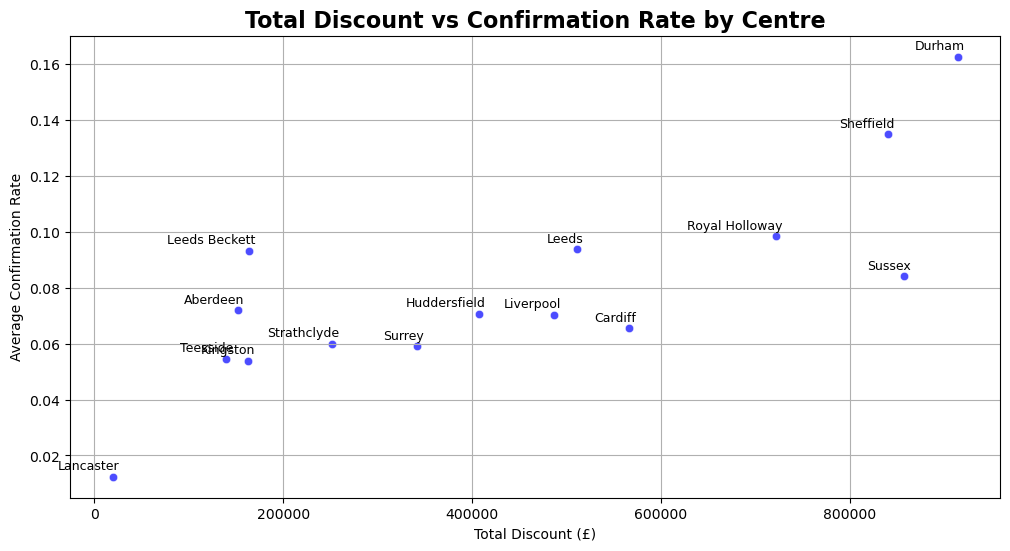

In [57]:
# Aggregate total discount and average confirmation rate by Centre
centre_discount_analysis = df.groupby("Centre").agg(
    total_discount=("Discount", "sum"),
    avg_confirmation_rate=("Confirmed", "mean")
).reset_index()

# Create scatter plot: Total Discount vs Confirmation Rate by Centre
plt.figure(figsize=(12, 6))
ax = sns.scatterplot(
    x=centre_discount_analysis["total_discount"],
    y=centre_discount_analysis["avg_confirmation_rate"],
    alpha=0.7,
    color="blue"
)

# Add center names as labels with slight offsets to prevent overlap
for i, row in centre_discount_analysis.iterrows():
    plt.annotate(
        row["Centre"], 
        (row["total_discount"], row["avg_confirmation_rate"]),
        textcoords="offset points",
        xytext=(5,5),  # Offset labels slightly to prevent overlap
        ha='right',
        fontsize=9
    )

# Titles and labels
plt.title("Total Discount vs Confirmation Rate by Centre", fontsize=16, weight="bold")
plt.xlabel("Total Discount (£)")
plt.ylabel("Average Confirmation Rate")
plt.grid(True)

plt.show()

This was made to visualize which centers seem to more responsive to discounts and a few centers stand out: Durham, Sheffield, Royal Holloway show high discounts and high confirmations.

# Correlation Analysis
### Initial Attempt with visualisation issue

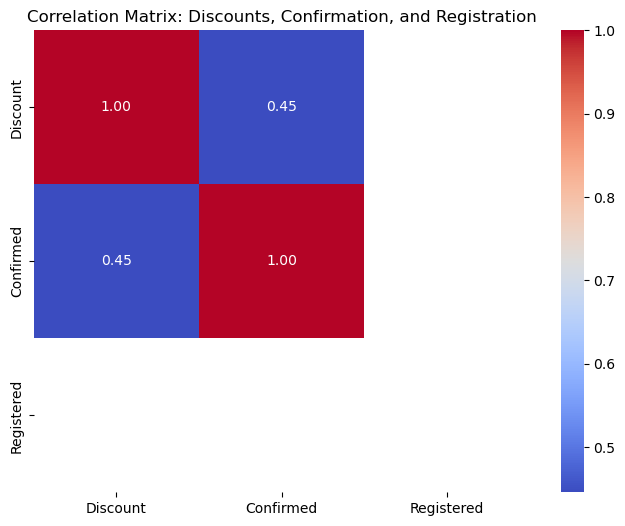

In [61]:
#Correlation between discounts and confirmation/registration rates

correlation_matrix = df[["Discount", "Confirmed", "Registered"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix: Discounts, Confirmation, and Registration")
plt.show()

No data shown for "Registered".

### Final Version using "Arrived" instead of "Registered"


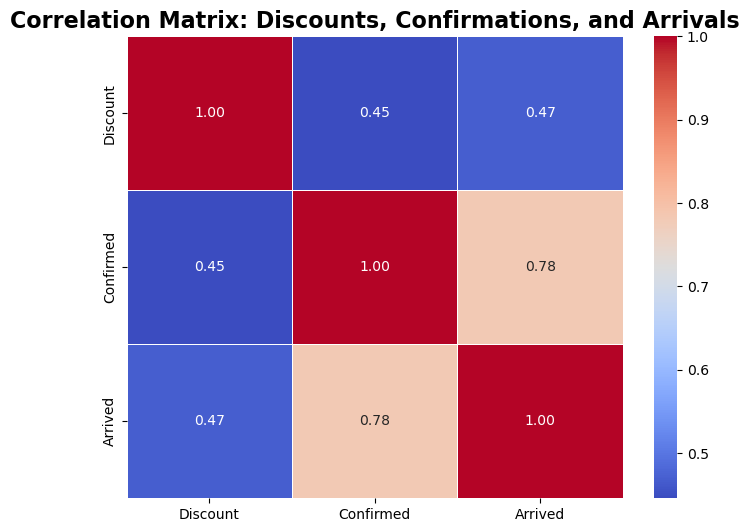

           Discount  Confirmed   Arrived
Discount   1.000000   0.445965  0.467961
Confirmed  0.445965   1.000000  0.783030
Arrived    0.467961   0.783030  1.000000


In [74]:
# Convert relevant columns to numeric or datetime
df["Confirmation Date"] = pd.to_datetime(df["Confirmation Date"], errors="coerce")
df["Arrived Date"] = pd.to_datetime(df["Arrived Date"], errors="coerce")

# Create binary columns for "Confirmed" and "Arrived"
df["Confirmed"] = df["Confirmation Date"].notna().astype(int)
df["Arrived"] = df["Arrived Date"].notna().astype(int)

# Compute the updated correlation matrix including "Arrived"
correlation_matrix_updated = df[["Discount", "Confirmed", "Arrived"]].corr()

# Create a heatmap with the updated correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_updated, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Titles and labels
plt.title("Correlation Matrix: Discounts, Confirmations, and Arrivals", fontsize=16, weight="bold")

# Show plot
plt.show()

# Print the correlation matrix values
print(correlation_matrix_updated)

Discounts have a moderate positive correlation (~0.45) with confirmations, meaning that higher discounts are somewhat associated with higher confirmation rates.
Correlation with registration is unfound in the first matrix.

However, discounts also moderately correlate with arrivals (~0.47) : Students who receive discounts are slightly more likely to arrive, meaning financial incentives play a role in final enrollment.
However, this correlation is not extremely strong, suggesting that other factors (visa issues, funding availability, personal decisions) impact arrival rates.

Confirmations strongly correlate with arrivals (~0.78): Students who confirm their spots are very likely to arrive.
This means that most students who commit to a program actually follow through and enroll.

# Visualisations Modifications based on Feedback
## Ranking bar plots order from > to < for clearer view
### Total Discount Distribution By Center

C:\Users\Jessy\AppData\Local\Temp\ipykernel_20652\3728462737.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Centre", y="Discount", data=discount_analysis, palette="Blues_r")  # "Blues_r" ensures darkest at highest value


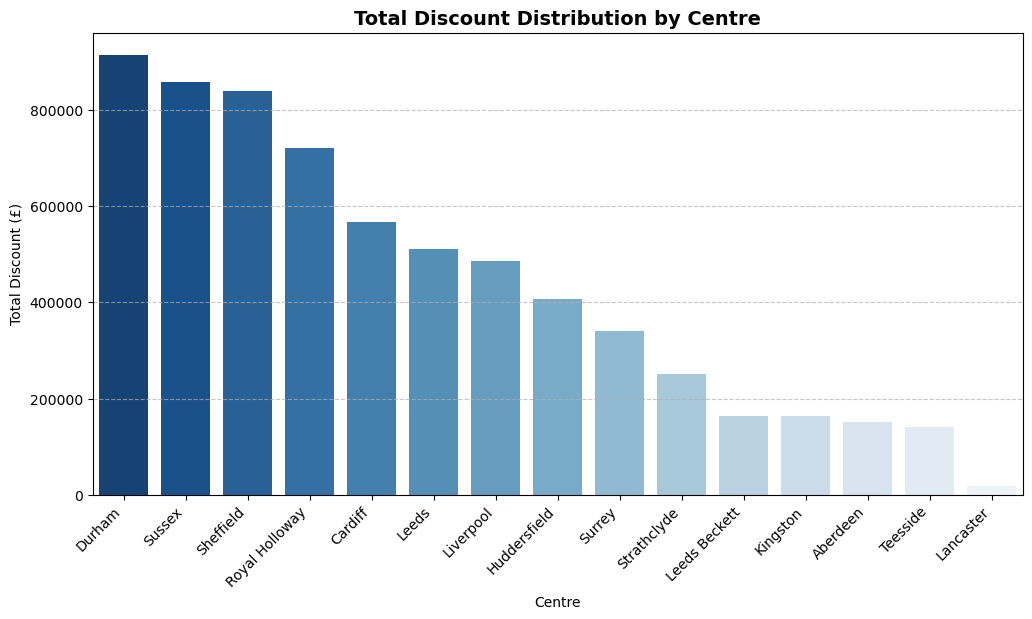

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Centre and calculate total discounts
discount_analysis = df.groupby(["Centre"])["Discount"].sum().reset_index()

# Sort by total discount in descending order
discount_analysis = discount_analysis.sort_values(by="Discount", ascending=False)

# Create the bar plot with a gradient color palette
plt.figure(figsize=(12, 6))
sns.barplot(x="Centre", y="Discount", data=discount_analysis, palette="Blues_r")  # "Blues_r" ensures darkest at highest value

# Formatting
plt.xticks(rotation=45, ha="right")  # Improve label readability
plt.title("Total Discount Distribution by Centre", fontsize=14, weight="bold")
plt.ylabel("Total Discount (£)")
plt.xlabel("Centre")
plt.grid(axis="y", linestyle="--", alpha=0.7)  # Light grid for clarity

# Show plot
plt.show()


### Total Discount Distribution by Region

C:\Users\Jessy\AppData\Local\Temp\ipykernel_20652\844545249.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Region", y="sum", data=discount_region, palette="Reds_r")  # "Reds_r" ensures darkest color for highest value


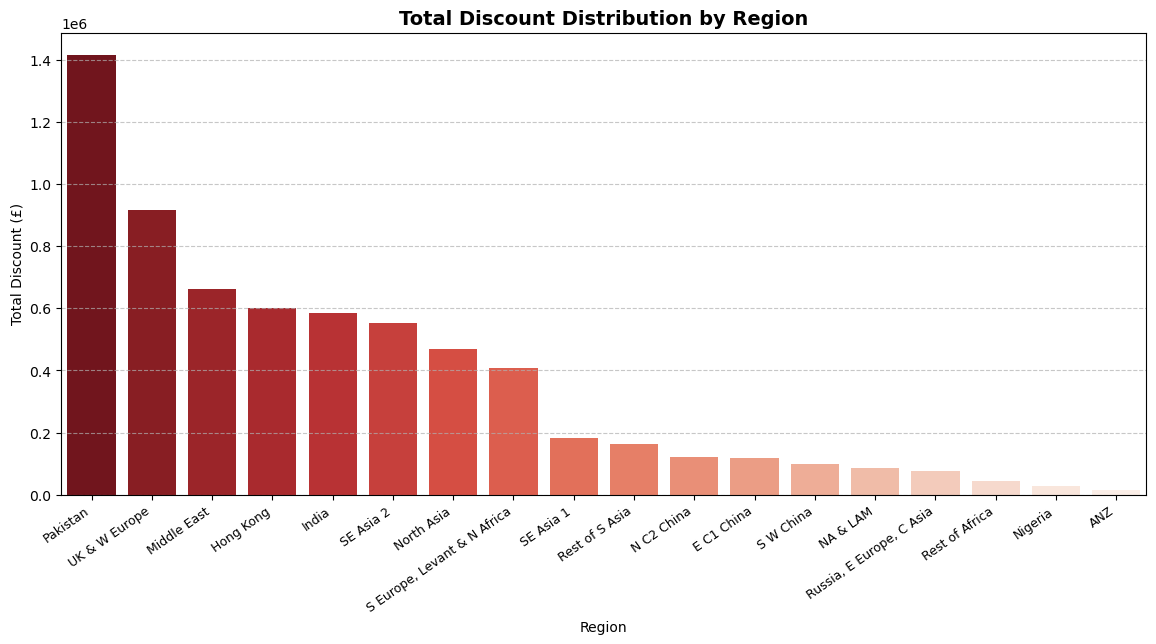

In [76]:
# Group by Region and calculate total discounts
discount_region = df.groupby(["Region"])["Discount"].agg(["sum", "mean"]).reset_index()

# Sort by total discount in descending order
discount_region = discount_region.sort_values(by="sum", ascending=False)

# Create the bar plot with a gradient color palette
plt.figure(figsize=(14, 6))
sns.barplot(x="Region", y="sum", data=discount_region, palette="Reds_r")  # "Reds_r" ensures darkest color for highest value

# Formatting
plt.xticks(rotation=35, ha="right", fontsize=9)  # Improve label readability
plt.title("Total Discount Distribution by Region", fontsize=14, weight="bold")
plt.ylabel("Total Discount (£)")
plt.xlabel("Region")
plt.grid(axis="y", linestyle="--", alpha=0.7)  # Light grid for clarity

# Show plot
plt.show()


### Average Discount by Region

C:\Users\Jessy\AppData\Local\Temp\ipykernel_20652\1396958979.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Region", y="mean", data=discount_region, palette="Blues_r")  # "Blues_r" ensures darkest color for highest value


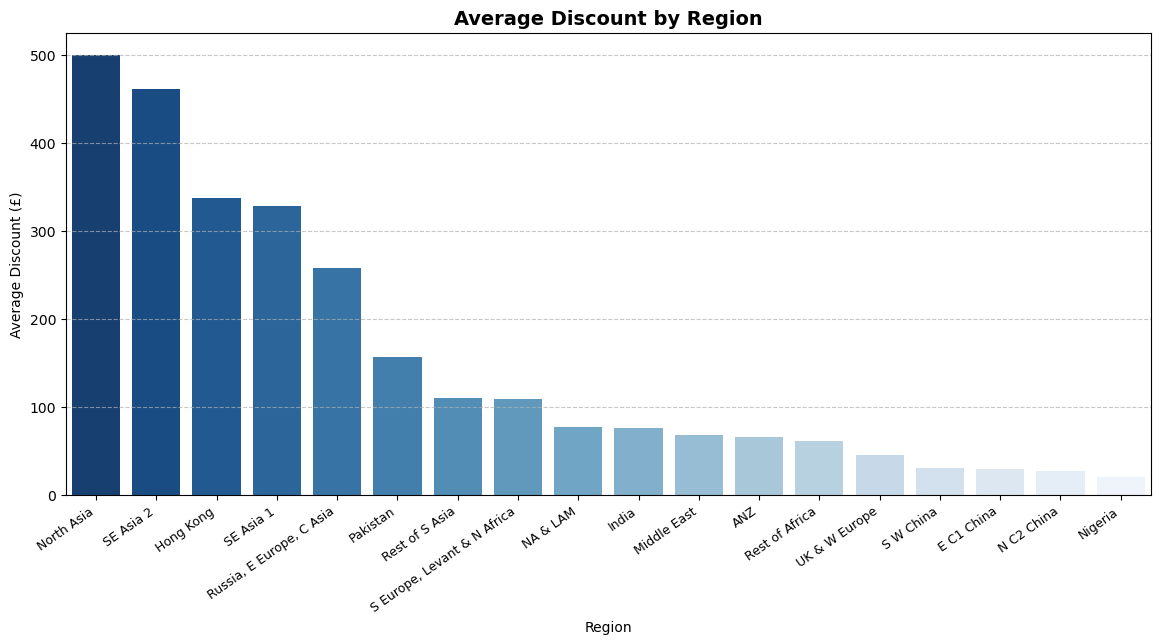

In [79]:
# Group by Region and calculate total and average discounts
discount_region = df.groupby(["Region"])["Discount"].agg(["sum", "mean"]).reset_index()

# Sort by average discount in descending order
discount_region = discount_region.sort_values(by="mean", ascending=False)

# Create the bar plot with a gradient color palette
plt.figure(figsize=(14, 6))
sns.barplot(x="Region", y="mean", data=discount_region, palette="Blues_r")  # "Blues_r" ensures darkest color for highest value

# Formatting
plt.xticks(rotation=35, ha="right", fontsize=9)  # Improve label readability
plt.title("Average Discount by Region", fontsize=14, weight="bold")
plt.ylabel("Average Discount (£)")
plt.xlabel("Region")
plt.grid(axis="y", linestyle="--", alpha=0.7)  # Light grid for clarity

# Show plot
plt.show()


### Discount Sensitivity by Region

C:\Users\Jessy\AppData\Local\Temp\ipykernel_20652\500952575.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Region", y="Confirmed", data=df_discount_region, palette="viridis_r")  # "viridis_r" ensures darkest color for highest value


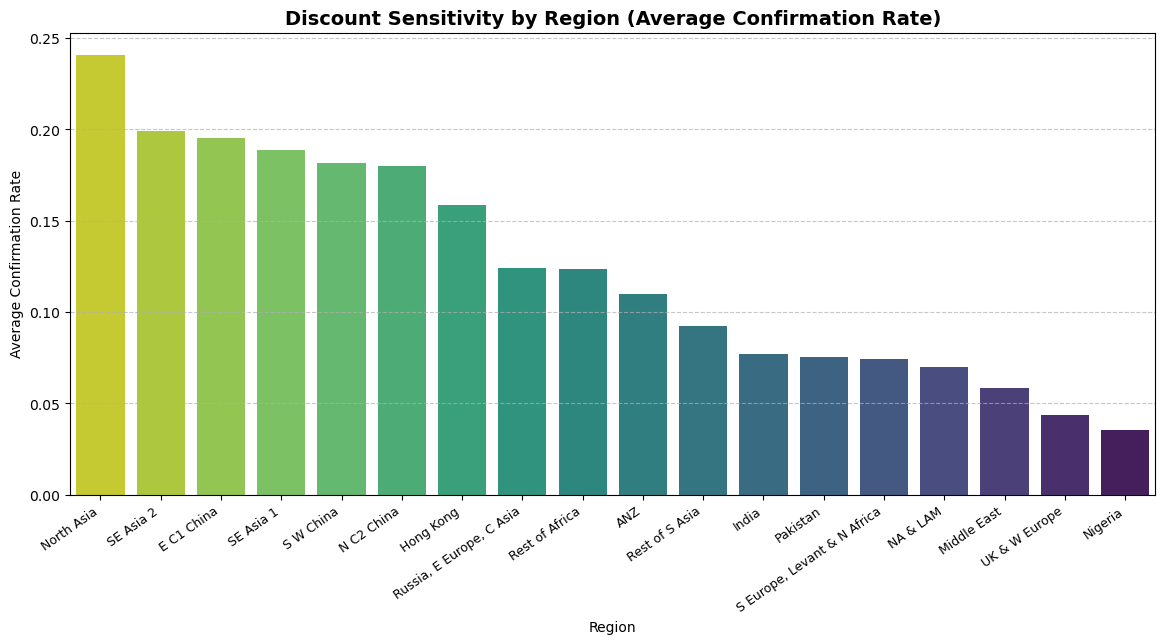

In [83]:
# Group by Region and calculate average confirmation rate
df_discount_region = df.groupby("Region")["Confirmed"].mean().reset_index()

# Sort by average confirmation rate in descending order
df_discount_region = df_discount_region.sort_values(by="Confirmed", ascending=False)

# Create the bar plot with a gradient color palette
plt.figure(figsize=(14, 6))
sns.barplot(x="Region", y="Confirmed", data=df_discount_region, palette="viridis_r")  # "viridis_r" ensures darkest color for highest value

# Formatting
plt.xticks(rotation=35, ha="right", fontsize=9)  # Improve label readability
plt.title("Discount Sensitivity by Region (Average Confirmation Rate)", fontsize=14, weight="bold")
plt.ylabel("Average Confirmation Rate")
plt.xlabel("Region")
plt.grid(axis="y", linestyle="--", alpha=0.7)  # Light grid for clarity

# Show plot
plt.show()
